In [1]:
!pip install chemprop rdkit pandas matplotlib scikit-learn pytorch-lightning

Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.0/853.0 kB 8.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 45.6 MB/s eta 0:00:00

[notice] A new release of pip is available: 23.3.2 -> 26.2.1
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

import chemprop
import pytorch_lightning as pl

print("Library berhasil di-import!")

Library berhasil di-import!


In [54]:
import pandas as pd

file_path = "USP5_chemprop.csv"

# 1. Coba baca file (otomatis mendeteksi pemisah koma atau titik koma)
try:
    df = pd.read_csv(file_path, sep=None, engine='python')
except Exception:
    df = pd.read_csv(file_path, sep=';')

print(df[['SMILES', 'pIC50']].head())

                                              SMILES     pIC50
0  O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(N3C(=O)Cc4cc...  3.886057
1                     O=C(O)CCc1nnc(-c2ccc(Cl)cc2)o1  3.346787
2     O=C(NCCc1ccc(Cl)cc1)c1ccc2nc3c(c(Cl)c2c1)CCCC3  3.698970
3  O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(N3CCOCC3)CC2...  4.346787
4  O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(c3ccc(F)cc3)...  4.638272


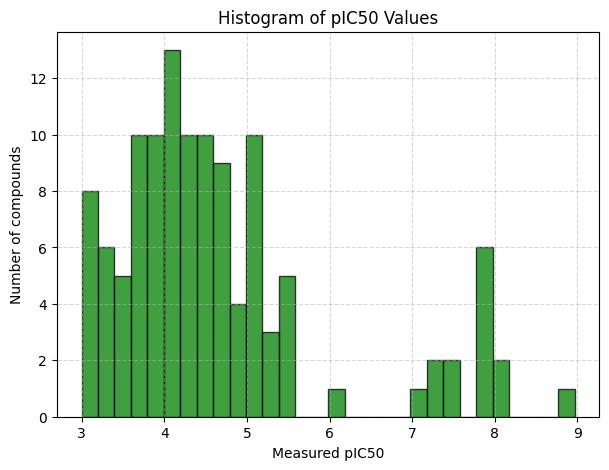

Gambar histogram berhasil dibuat dan disimpan ke: Histogram of pIC50 Values.png


In [110]:
import matplotlib.pyplot as plt

# 1. Plot Histogram Distribusi pIC50
plt.figure(figsize=(7, 5))
plt.hist(df['pIC50'], bins=30, facecolor='green', alpha=0.75, edgecolor='black')
plt.xlabel('Measured pIC50')
plt.ylabel('Number of compounds')
plt.title('Histogram of pIC50 Values')
plt.grid(True, linestyle='--', alpha=0.5)

# 2. Menyimpan gambar langsung ke folder kerja (/Zira/)
histogram_path = "Histogram of pIC50 Values.png"
plt.savefig(histogram_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Gambar histogram berhasil dibuat dan disimpan ke: {histogram_path}")

In [56]:
import chemprop

print("Memulai proses pelatihan model D-MPNN Chemprop...")

# 1. Menyiapkan konfigurasi pelatihan Chemprop v1.6.1
args_train = chemprop.args.TrainArgs().parse_args([
    '--data_path', 'train.csv',
    '--separate_val_path', 'valid.csv',
    '--separate_test_path', 'test.csv',
    '--dataset_type', 'regression',
    '--target_columns', 'pIC50',
    '--save_dir', 'usp5_model_1',
    '--epochs', '100',
    '--batch_size', '10',
    '--metric', 'rmse',
    '--quiet'
])

Train : 82
Valid : 34
Test  : 2


In [57]:
import chemprop

print("Chemprop version:", chemprop.__version__)

Chemprop version: 1.6.1


In [58]:
import inspect
import chemprop.train

print(dir(chemprop.train))

['TRAIN_LOGGER_NAME', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'accuracy', 'bce', 'bounded_mae', 'bounded_mse', 'bounded_mse_loss', 'bounded_rmse', 'chemprop_fingerprint', 'chemprop_predict', 'chemprop_train', 'cross_validate', 'evaluate', 'evaluate_predictions', 'f1_metric', 'get_loss_func', 'get_metric_func', 'load_data', 'load_model', 'loss_functions', 'make_predictions', 'mcc_class_loss', 'mcc_metric', 'mcc_multiclass_loss', 'metrics', 'model_fingerprint', 'molecule_fingerprint', 'prc_auc', 'predict', 'predict_and_save', 'rmse', 'run_training', 'set_features', 'sid_loss', 'sid_metric', 'train', 'wasserstein_loss', 'wasserstein_metric']


In [59]:
import inspect
from chemprop.train import cross_validate

print(inspect.signature(cross_validate))

(args: chemprop.args.TrainArgs, train_func: Callable[[chemprop.args.TrainArgs, chemprop.data.data.MoleculeDataset, logging.Logger], Dict[str, List[float]]]) -> Tuple[float, float]


In [60]:
from chemprop.train import run_training

print(inspect.signature(run_training))

(args: chemprop.args.TrainArgs, data: chemprop.data.data.MoleculeDataset, logger: logging.Logger = None) -> Dict[str, List[float]]


In [61]:
import inspect
from chemprop.args import TrainArgs

print(inspect.signature(TrainArgs))

(*args, **kwargs) -> None


In [62]:
from chemprop.args import TrainArgs

args = TrainArgs()
args.parse_args(["--help"])

usage: ipykernel_launcher.py --data_path DATA_PATH
                             [--target_columns [TARGET_COLUMNS ...]]
                             [--ignore_columns [IGNORE_COLUMNS ...]]
                             --dataset_type
                             {regression,classification,multiclass,spectra}
                             [--loss_function {mse,bounded_mse,binary_cross_entropy,cross_entropy,mcc,sid,wasserstein,mve,evidential,dirichlet}]
                             [--multiclass_num_classes MULTICLASS_NUM_CLASSES]
                             [--separate_val_path SEPARATE_VAL_PATH]
                             [--separate_test_path SEPARATE_TEST_PATH]
                             [--spectra_phase_mask_path SPECTRA_PHASE_MASK_PATH]
                             [--data_weights_path DATA_WEIGHTS_PATH]
                             [--target_weights [TARGET_WEIGHTS ...]]
                             [--split_type {random,scaffold_balanced,predetermined,crossval,cv,cv-no-test,in

SystemExit: 0

/usr/local/lib/python3.10/dist-packages/IPython/core/interactiveshell.py:3561: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [76]:
chemprop_df = df[["SMILES", "pIC50"]].copy()

chemprop_df.to_csv(
    "/data/Zira/USP5_chemprop.csv",
    index=False
)

print(chemprop_df.shape)
chemprop_df.head()

(118, 2)


,SMILES,pIC50
0,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(N3C(=O)Cc4cc...,3.886057
1,O=C(O)CCc1nnc(-c2ccc(Cl)cc2)o1,3.346787
2,O=C(NCCc1ccc(Cl)cc1)c1ccc2nc3c(c(Cl)c2c1)CCCC3,3.698970
3,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(N3CCOCC3)CC2...,4.346787
4,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(c3ccc(F)cc3)...,4.638272


In [113]:
from chemprop.args import TrainArgs

args = TrainArgs().parse_args([
    "--data_path", "/data/Zira/USP5_chemprop.csv",
    "--dataset_type", "regression",
    "--target_columns", "pIC50",
    "--smiles_columns", "SMILES",
    
    "--split_type", "random",
    "--split_sizes", "0.7", "0.29", "0.01",
    
    "--seed", "42",
    "--pytorch_seed", "42",
    
    "--metric", "rmse",
    "--extra_metrics", "mae", "r2",
    
    "--batch_size", "10",
    "--epochs", "100",
    
    "--save_dir", "/data/Zira/USP5_chemprop_model_notebook",
    "--save_preds",
    "--save_smiles_splits"
])

print("Konfigurasi Chemprop berhasil dibuat.")

Konfigurasi Chemprop berhasil dibuat.


In [90]:
print("Dataset       :", args.data_path)
print("Target        :", args.target_columns)
print("SMILES        :", args.smiles_columns)
print("Dataset type  :", args.dataset_type)
print("Split         :", args.split_type)
print("Split sizes   :", args.split_sizes)
print("Batch size    :", args.batch_size)
print("Epochs        :", args.epochs)
print("Metric        :", args.metric)

Dataset       : /data/Zira/USP5_chemprop.csv
Target        : ['pIC50']
SMILES        : ['SMILES']
Dataset type  : regression
Split         : random
Split sizes   : [0.7, 0.29, 0.01]
Batch size    : 10
Epochs        : 100
Metric        : rmse


In [94]:
import os

model_dir = "/data/Zira/USP5_chemprop_model_notebook"

for root, dirs, files in os.walk(model_dir):
    level = root.replace(model_dir, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")
    
    for file in files:
        print(f"{indent}    {file}")

USP5_chemprop_model_notebook/
    quiet.log
    test_preds.csv
    args.json
    test_scores.csv
    verbose.log
    fold_0/
        test_smiles.csv
        val_full.csv
        train_smiles.csv
        test_preds.csv
        train_full.csv
        val_smiles.csv
        test_scores.json
        test_full.csv
        model_0/
            events.out.tfevents.1791529115.13a9c4208f46
            model.pt


In [95]:
import os

model_dir = "/data/Zira/USP5_chemprop_model_notebook"

print("Folder ada:", os.path.exists(model_dir))

if os.path.exists(model_dir):
    for root, dirs, files in os.walk(model_dir):
        print("\n", root)
        for file in files:
            print("   ", file)

Folder ada: True

 /data/Zira/USP5_chemprop_model_notebook
    quiet.log
    test_preds.csv
    args.json
    test_scores.csv
    verbose.log

 /data/Zira/USP5_chemprop_model_notebook/fold_0
    test_smiles.csv
    val_full.csv
    train_smiles.csv
    test_preds.csv
    train_full.csv
    val_smiles.csv
    test_scores.json
    test_full.csv

 /data/Zira/USP5_chemprop_model_notebook/fold_0/model_0
    events.out.tfevents.1791529115.13a9c4208f46
    model.pt


In [96]:
import os

model_dir = "/data/Zira/USP5_chemprop_model_notebook"

for root, dirs, files in os.walk(model_dir):
    print(root)
    for file in files:
        print("   ", file)

/data/Zira/USP5_chemprop_model_notebook
    quiet.log
    test_preds.csv
    args.json
    test_scores.csv
    verbose.log
/data/Zira/USP5_chemprop_model_notebook/fold_0
    test_smiles.csv
    val_full.csv
    train_smiles.csv
    test_preds.csv
    train_full.csv
    val_smiles.csv
    test_scores.json
    test_full.csv
/data/Zira/USP5_chemprop_model_notebook/fold_0/model_0
    events.out.tfevents.1791529115.13a9c4208f46
    model.pt


In [97]:
import pandas as pd

model_path = "/data/Zira/USP5_chemprop_model_notebook/fold_0/model_0/model.pt"

train_data = pd.read_csv(
    "/data/Zira/USP5_chemprop_model_notebook/fold_0/train_full.csv"
)

val_data = pd.read_csv(
    "/data/Zira/USP5_chemprop_model_notebook/fold_0/val_full.csv"
)

print("Train :", train_data.shape)
print("Validation :", val_data.shape)

print("\nKolom train:")
print(train_data.columns.tolist())

print("\n5 data train:")
display(train_data.head())

Train : (82, 2)
Validation : (34, 2)

Kolom train:
['SMILES', 'pIC50']

5 data train:


,SMILES,pIC50
0,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(c3ccc(Br)cc3...,4.886057
1,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC3(CC2)OCc2ccc...,3.657577
2,O=C(Cc1ccccc1)Oc1c(OC(=O)Cc2ccccc2)c(-c2ccc(O)...,4.903090
3,COc1ccc(Br)c(-c2nnc(CCC(=O)O)o2)c1,3.568636
4,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(c3ccc(Cl)cc3...,4.585027


In [98]:
import inspect
from chemprop.train import make_predictions

print(inspect.signature(make_predictions))

(args: chemprop.args.PredictArgs, smiles: List[List[str]] = None, model_objects: Tuple[chemprop.args.PredictArgs, chemprop.args.TrainArgs, List[chemprop.models.model.MoleculeModel], List[Union[chemprop.data.scaler.StandardScaler, chemprop.data.scaler.AtomBondScaler]], int, List[str]] = None, calibrator: chemprop.uncertainty.uncertainty_calibrator.UncertaintyCalibrator = None, return_invalid_smiles: bool = True, return_index_dict: bool = False, return_uncertainty: bool = False) -> List[List[Optional[float]]]


In [99]:
from chemprop.args import PredictArgs

pred_args = PredictArgs().parse_args([
    "--test_path",
    "/data/Zira/USP5_chemprop_model_notebook/fold_0/train_full.csv",
    "--checkpoint_path",
    "/data/Zira/USP5_chemprop_model_notebook/fold_0/model_0/model.pt",
    "--preds_path",
    "/data/Zira/USP5_chemprop_model_notebook/fold_0/train_predictions.csv"
])

print("PredictArgs berhasil dibuat.")

PredictArgs berhasil dibuat.


In [100]:
from chemprop.train import make_predictions

pred_train = make_predictions(pred_args)

print("Jumlah prediksi:", len(pred_train))
print("5 prediksi pertama:")
print(pred_train[:5])

Loading training args
Setting molecule featurization parameters to default.
Loading data


82it [00:00, 182651.58it/s]
100%|██████████| 82/82 [00:00<00:00, 107951.33it/s]


Validating SMILES
Test size = 82


  0%|          | 0/1 [00:00<?, ?it/s]

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Moving model to cuda



100%|██████████| 1/1 [00:00<00:00,  1.88it/s]

Saving predictions to /data/Zira/USP5_chemprop_model_notebook/fold_0/train_predictions.csv
Elapsed time = 0:00:01
Jumlah prediksi: 82
5 prediksi pertama:
[[4.45604166137423], [4.189175341234563], [4.93989507009721], [3.53957899142463], [4.5487829151016195]]


In [101]:
train_result = train_data.copy()

train_result["Predicted_pIC50"] = [
    x[0] if x is not None else None
    for x in pred_train
]

display(train_result.head(10))

,SMILES,pIC50,Predicted_pIC50
0,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(c3ccc(Br)cc3...,4.886057,4.456042
1,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC3(CC2)OCc2ccc...,3.657577,4.189175
2,O=C(Cc1ccccc1)Oc1c(OC(=O)Cc2ccccc2)c(-c2ccc(O)...,4.903090,4.939895
3,COc1ccc(Br)c(-c2nnc(CCC(=O)O)o2)c1,3.568636,3.539579
4,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(c3ccc(Cl)cc3...,4.585027,4.548783
5,CC(C)c1ccc(C(=O)CCC(=O)O)cc1,4.096910,3.856162
6,Cc1cc(C(=O)NCC(=O)O)ccc1S(=O)(=O)N1CCC(c2ccccc...,4.229148,4.361134
7,Cc1cc(C(=O)CN2CCCC2)c(C)n1-c1ccc(F)cc1,3.843451,4.231183
8,N#CSc1cc(SC#N)c(N)nc1N,5.065502,4.958782
9,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(c3ccccc3)C2)cc1,3.886057,4.185673


In [102]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_train = train_result["pIC50"]
y_pred_train = train_result["Predicted_pIC50"]

train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
train_mae = mean_absolute_error(y_train, y_pred_train)
train_r2 = r2_score(y_train, y_pred_train)

print("TRAIN PERFORMANCE")
print(f"RMSE : {train_rmse:.4f}")
print(f"MAE  : {train_mae:.4f}")
print(f"R²   : {train_r2:.4f}")

TRAIN PERFORMANCE
RMSE : 0.5779
MAE  : 0.3673
R²   : 0.8288


In [103]:
from chemprop.args import PredictArgs
from chemprop.train import make_predictions

val_pred_args = PredictArgs().parse_args([
    "--test_path",
    "/data/Zira/USP5_chemprop_model_notebook/fold_0/val_full.csv",
    "--checkpoint_path",
    "/data/Zira/USP5_chemprop_model_notebook/fold_0/model_0/model.pt",
    "--preds_path",
    "/data/Zira/USP5_chemprop_model_notebook/fold_0/val_predictions.csv"
])

pred_valid = make_predictions(val_pred_args)

print("Jumlah prediksi validation:", len(pred_valid))
print("5 prediksi pertama:")
print(pred_valid[:5])

Loading training args
Setting molecule featurization parameters to default.
Loading data


34it [00:00, 149954.09it/s]
100%|██████████| 34/34 [00:00<00:00, 108281.20it/s]


Validating SMILES
Test size = 34


  0%|          | 0/1 [00:00<?, ?it/s]

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Moving model to cuda



100%|██████████| 1/1 [00:00<00:00,  2.13it/s]

Saving predictions to /data/Zira/USP5_chemprop_model_notebook/fold_0/val_predictions.csv
Elapsed time = 0:00:01
Jumlah prediksi validation: 34
5 prediksi pertama:
[[4.282732174221833], [4.431013256447928], [4.548782941115081], [3.693304899332081], [4.353119982106417]]


In [105]:
val_result = val_data.copy()

val_result["Predicted_pIC50"] = [
    x[0] if x is not None else None
    for x in pred_valid
]

display(val_result.head(10))

,SMILES,pIC50,Predicted_pIC50
0,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(N3C(=O)Cc4cc...,3.886057,4.282732
1,COc1cccc(C2CCN(S(=O)(=O)c3ccc(C(=O)NCC(=O)O)cc...,4.408935,4.431013
2,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(c3ccc(Cl)cc3...,5.154902,4.548783
3,O=C(O)Cn1cnc2ccccc2c1=O,3.657577,3.693305
4,CC1CC(c2ccccc2)CCN1S(=O)(=O)c1ccc(C(=O)NCC(=O)...,4.036212,4.353120
5,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCc3ccccc3C2)cc1,3.958607,3.974779
6,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CC(c3ccccc3)C2)cc1,3.568636,4.042789
7,COc1ccccc1CN(C)C(=O)Cn1c(CCC(=O)O)nc2c(Cl)cccc...,5.200659,4.440439
8,CC(C)C[C@@H](NC(=O)C1(C(F)(F)F)CCCCC1)C(=O)Nc1...,7.823909,7.754177
9,O=C(O)CNC(=O)c1ccc(S(=O)(=O)N2CCC(Oc3ccccc3)CC...,4.214670,4.292435


In [106]:
y_valid = val_result["pIC50"]
y_pred_valid = val_result["Predicted_pIC50"]

valid_rmse = np.sqrt(mean_squared_error(y_valid, y_pred_valid))
valid_mae = mean_absolute_error(y_valid, y_pred_valid)
valid_r2 = r2_score(y_valid, y_pred_valid)

print("VALIDATION PERFORMANCE")
print(f"RMSE : {valid_rmse:.4f}")
print(f"MAE  : {valid_mae:.4f}")
print(f"R²   : {valid_r2:.4f}")

VALIDATION PERFORMANCE
RMSE : 0.6109
MAE  : 0.4108
R²   : 0.7066


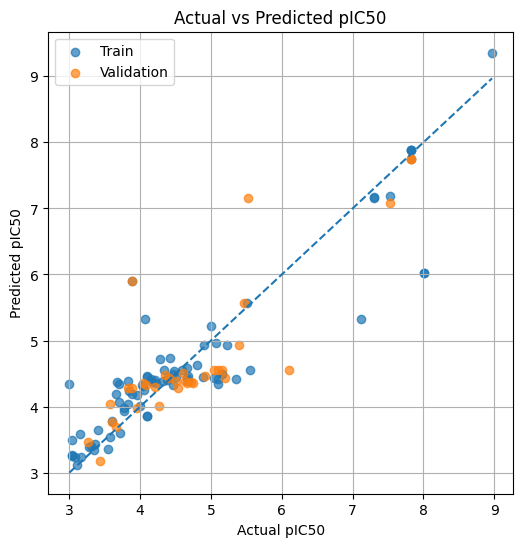

In [108]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))

plt.scatter(
    train_result["pIC50"],
    train_result["Predicted_pIC50"],
    alpha=0.7,
    label="Train"
)

plt.scatter(
    val_result["pIC50"],
    val_result["Predicted_pIC50"],
    alpha=0.7,
    label="Validation"
)

# Garis ideal y = x
min_value = min(
    train_result["pIC50"].min(),
    val_result["pIC50"].min()
)

max_value = max(
    train_result["pIC50"].max(),
    val_result["pIC50"].max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Actual vs Predicted pIC50")
plt.legend()
plt.grid(True)

plt.savefig(
    "/data/Zira/USP5_chemprop_model_notebook/actual_vs_predicted_pIC50.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [115]:
import pandas as pd

url = "/data/Zira/analog kurkumin kurasi.csv"

analog_df = pd.read_csv(url)

print("Jumlah senyawa:", len(analog_df))
print("Kolom:", analog_df.columns.tolist())

display(analog_df.head())

Jumlah senyawa: 2382
Kolom: ['Compound ChEMBL ID', 'Smiles', 'Smiles (RDKit Mol)']


,Compound ChEMBL ID,Smiles,Smiles (RDKit Mol)
0,CHEMBL151562,C/N=C(\N)c1ccc(/C=C2/CCCC/C(=C/c3ccc(C(=N)N)cc...,C/N=C(\N)c1ccc(/C=C2/CCCC/C(=C/c3ccc(C(=N)N)cc...
1,CHEMBL1630638,O=C1/C(=C/c2ccc(N3CCOCC3)cc2)CC/C1=C\c1ccc(N2C...,O=C1/C(=C/c2ccc(N3CCOCC3)cc2)CC/C1=C\c1ccc(N2C...
2,CHEMBL150612,N=C(N)c1ccc(/C=C2/CC(c3ccccc3)C/C(=C\c3ccc(C(=...,N=C(N)c1ccc(/C=C2/CC(c3ccccc3)C/C(=C\c3ccc(C(=...
3,CHEMBL5284389,CC1(C)C=C(CN2C/C(=C\c3ccc(F)cc3)C(=O)/C(=C/c3c...,CC1(C)C=C(CN2C/C(=C\c3ccc(F)cc3)C(=O)/C(=C/c3c...
4,CHEMBL406574,O=C1/C(=C/c2ccc(O)c(Br)c2)CSC/C1=C\c1ccc(O)c(B...,O=C1/C(=C/c2ccc(O)c(Br)c2)CSC/C1=C\c1ccc(O)c(B...


In [116]:
analog_predict = analog_df[["Smiles"]].copy()

analog_predict.to_csv(
    "/data/Zira/analog_kurkumin_predict.csv",
    index=False
)

display(analog_predict.head())

,Smiles
0,C/N=C(\N)c1ccc(/C=C2/CCCC/C(=C/c3ccc(C(=N)N)cc...
1,O=C1/C(=C/c2ccc(N3CCOCC3)cc2)CC/C1=C\c1ccc(N2C...
2,N=C(N)c1ccc(/C=C2/CC(c3ccccc3)C/C(=C\c3ccc(C(=...
3,CC1(C)C=C(CN2C/C(=C\c3ccc(F)cc3)C(=O)/C(=C/c3c...
4,O=C1/C(=C/c2ccc(O)c(Br)c2)CSC/C1=C\c1ccc(O)c(B...


In [117]:
from chemprop.args import PredictArgs
from chemprop.train import make_predictions

pred_args = PredictArgs().parse_args([
    "--test_path",
    "/data/Zira/analog_kurkumin_predict.csv",

    "--checkpoint_path",
    "/data/Zira/USP5_chemprop_model_notebook/fold_0/model_0/model.pt",

    "--preds_path",
    "/data/Zira/analog_kurkumin_predictions.csv"
])

predicted_pIC50 = make_predictions(pred_args)

print("Jumlah prediksi:", len(predicted_pIC50))
print("5 prediksi pertama:")
print(predicted_pIC50[:5])

Loading training args
Setting molecule featurization parameters to default.
Loading data


2382it [00:00, 230378.68it/s]
100%|██████████| 2382/2382 [00:00<00:00, 151628.96it/s]

Validating SMILES


Test size = 2,382


  0%|          | 0/1 [00:00<?, ?it/s]

Loading pretrained parameter "encoder.encoder.0.cached_zero_vector".
Loading pretrained parameter "encoder.encoder.0.W_i.weight".
Loading pretrained parameter "encoder.encoder.0.W_h.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.weight".
Loading pretrained parameter "encoder.encoder.0.W_o.bias".
Loading pretrained parameter "readout.1.weight".
Loading pretrained parameter "readout.1.bias".
Loading pretrained parameter "readout.4.weight".
Loading pretrained parameter "readout.4.bias".
Moving model to cuda



100%|██████████| 1/1 [00:03<00:00,  3.79s/it]  

Saving predictions to /data/Zira/analog_kurkumin_predictions.csv
Elapsed time = 0:00:05
Jumlah prediksi: 2382
5 prediksi pertama:
[[4.266390163679203], [4.440967338856443], [4.1799853886610014], [5.435104624392288], [4.603220428355413]]


In [118]:
analog_result = analog_df[["Smiles"]].copy()

analog_result["Predicted_pIC50"] = [
    x[0] if x is not None else None
    for x in predicted_pIC50
]

display(analog_result.head())

,Smiles,Predicted_pIC50
0,C/N=C(\N)c1ccc(/C=C2/CCCC/C(=C/c3ccc(C(=N)N)cc...,4.266390
1,O=C1/C(=C/c2ccc(N3CCOCC3)cc2)CC/C1=C\c1ccc(N2C...,4.440967
2,N=C(N)c1ccc(/C=C2/CC(c3ccccc3)C/C(=C\c3ccc(C(=...,4.179985
3,CC1(C)C=C(CN2C/C(=C\c3ccc(F)cc3)C(=O)/C(=C/c3c...,5.435105
4,O=C1/C(=C/c2ccc(O)c(Br)c2)CSC/C1=C\c1ccc(O)c(B...,4.603220


In [119]:
print("Jumlah data:", len(analog_df))
print("Jumlah prediksi:", len(predicted_pIC50))

Jumlah data: 2382
Jumlah prediksi: 2382


In [120]:
analog_result = analog_df.copy()

analog_result["Predicted_pIC50"] = [
    x[0] if x is not None else None
    for x in predicted_pIC50
]

print("Jumlah hasil:", len(analog_result))

display(analog_result.head())

Jumlah hasil: 2382


,Compound ChEMBL ID,Smiles,Smiles (RDKit Mol),Predicted_pIC50
0,CHEMBL151562,C/N=C(\N)c1ccc(/C=C2/CCCC/C(=C/c3ccc(C(=N)N)cc...,C/N=C(\N)c1ccc(/C=C2/CCCC/C(=C/c3ccc(C(=N)N)cc...,4.266390
1,CHEMBL1630638,O=C1/C(=C/c2ccc(N3CCOCC3)cc2)CC/C1=C\c1ccc(N2C...,O=C1/C(=C/c2ccc(N3CCOCC3)cc2)CC/C1=C\c1ccc(N2C...,4.440967
2,CHEMBL150612,N=C(N)c1ccc(/C=C2/CC(c3ccccc3)C/C(=C\c3ccc(C(=...,N=C(N)c1ccc(/C=C2/CC(c3ccccc3)C/C(=C\c3ccc(C(=...,4.179985
3,CHEMBL5284389,CC1(C)C=C(CN2C/C(=C\c3ccc(F)cc3)C(=O)/C(=C/c3c...,CC1(C)C=C(CN2C/C(=C\c3ccc(F)cc3)C(=O)/C(=C/c3c...,5.435105
4,CHEMBL406574,O=C1/C(=C/c2ccc(O)c(Br)c2)CSC/C1=C\c1ccc(O)c(B...,O=C1/C(=C/c2ccc(O)c(Br)c2)CSC/C1=C\c1ccc(O)c(B...,4.603220


In [121]:
print("Total senyawa:", len(analog_result))
print("Prediksi berhasil:", analog_result["Predicted_pIC50"].notna().sum())
print("Prediksi gagal:", analog_result["Predicted_pIC50"].isna().sum())

Total senyawa: 2382
Prediksi berhasil: 2382
Prediksi gagal: 0


In [122]:
display(analog_result)

,Compound ChEMBL ID,Smiles,Smiles (RDKit Mol),Predicted_pIC50
0,CHEMBL151562,C/N=C(\N)c1ccc(/C=C2/CCCC/C(=C/c3ccc(C(=N)N)cc...,C/N=C(\N)c1ccc(/C=C2/CCCC/C(=C/c3ccc(C(=N)N)cc...,4.266390
1,CHEMBL1630638,O=C1/C(=C/c2ccc(N3CCOCC3)cc2)CC/C1=C\c1ccc(N2C...,O=C1/C(=C/c2ccc(N3CCOCC3)cc2)CC/C1=C\c1ccc(N2C...,4.440967
2,CHEMBL150612,N=C(N)c1ccc(/C=C2/CC(c3ccccc3)C/C(=C\c3ccc(C(=...,N=C(N)c1ccc(/C=C2/CC(c3ccccc3)C/C(=C\c3ccc(C(=...,4.179985
3,CHEMBL5284389,CC1(C)C=C(CN2C/C(=C\c3ccc(F)cc3)C(=O)/C(=C/c3c...,CC1(C)C=C(CN2C/C(=C\c3ccc(F)cc3)C(=O)/C(=C/c3c...,5.435105
4,CHEMBL406574,O=C1/C(=C/c2ccc(O)c(Br)c2)CSC/C1=C\c1ccc(O)c(B...,O=C1/C(=C/c2ccc(O)c(Br)c2)CSC/C1=C\c1ccc(O)c(B...,4.603220
...,...,...,...,...
2377,CHEMBL494974,O=C1/C(=C/c2ccccc2)CCC/C1=C\c1cccc([N+](=O)[O-...,O=C1/C(=C/c2ccccc2)CCC/C1=C\c1cccc([N+](=O)[O-...,5.485142
2378,CHEMBL493981,CN(C)c1ccc(/C=C2\CCC/C(=C\c3ccc([N+](=O)[O-])c...,CN(C)c1ccc(/C=C2\CCC/C(=C\c3ccc([N+](=O)[O-])c...,5.520788
2379,CHEMBL4755790,CCOP(=O)(OCC)C(c1ccc(OC)c(OC)c1OC)N1C/C(=C\c2c...,CCOP(=O)(OCC)C(c1ccc(OC)c(OC)c1OC)N1C/C(=C\c2c...,5.786876
2380,CHEMBL5396080,COc1cc(/C=C/C(=O)C(=Cc2ccc(O)c(F)c2)C(=O)/C=C/...,COc1cc(/C=C/C(=O)C(=Cc2ccc(O)c(F)c2)C(=O)/C=C/...,6.084175


In [123]:
analog_result.to_csv(
    "/data/Zira/hasil_prediksi_analog_kurkumin_Draft_1.csv",
    index=False
)

print("File berhasil disimpan.")

File berhasil disimpan.
